In [ ]:
!pip -q install "pillow<12" --upgrade

In [ ]:
!pip -q install -U scikit-learn matplotlib tqdm "pillow<12"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 111.1 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.19.0
GPU available: True


In [ ]:
!pip -q install gdown

import gdown

file_id = "195JUiCS-7vDX3fg3QHuBAdrmNxG8xGLd"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "archive.zip", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=195JUiCS-7vDX3fg3QHuBAdrmNxG8xGLd
From (redirected): https://drive.google.com/uc?id=195JUiCS-7vDX3fg3QHuBAdrmNxG8xGLd&confirm=t&uuid=55809878-6862-41e2-b508-c03755d91251
To: /content/archive.zip
100%|██████████| 156M/156M [00:04<00:00, 37.7MB/s]


'archive.zip'

In [ ]:
!unzip -q archive.zip


In [ ]:
print(os.listdir('.'))


['.config', 'Training', 'Testing', 'archive.zip', 'sample_data']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (256, 256)
BATCH = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    "Training",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    "Training",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "Testing",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

print("Train:", train_gen.samples)
print("Val:", val_gen.samples)
print("Test:", test_gen.samples)
print("Classes:", train_gen.class_indices)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Train: 4571
Val: 1141
Test: 1311
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

import os
import random
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout



In [ ]:
import os

def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

train_dir = "Training"
test_dir  = "Testing"

train_counts = count_images_per_class(train_dir)
test_counts  = count_images_per_class(test_dir)

print("Training class counts:", train_counts)
print("Testing class counts:", test_counts)


Training class counts: {'notumor': 1595, 'meningioma': 1339, 'pituitary': 1457, 'glioma': 1321}
Testing class counts: {'notumor': 405, 'meningioma': 306, 'pituitary': 300, 'glioma': 300}


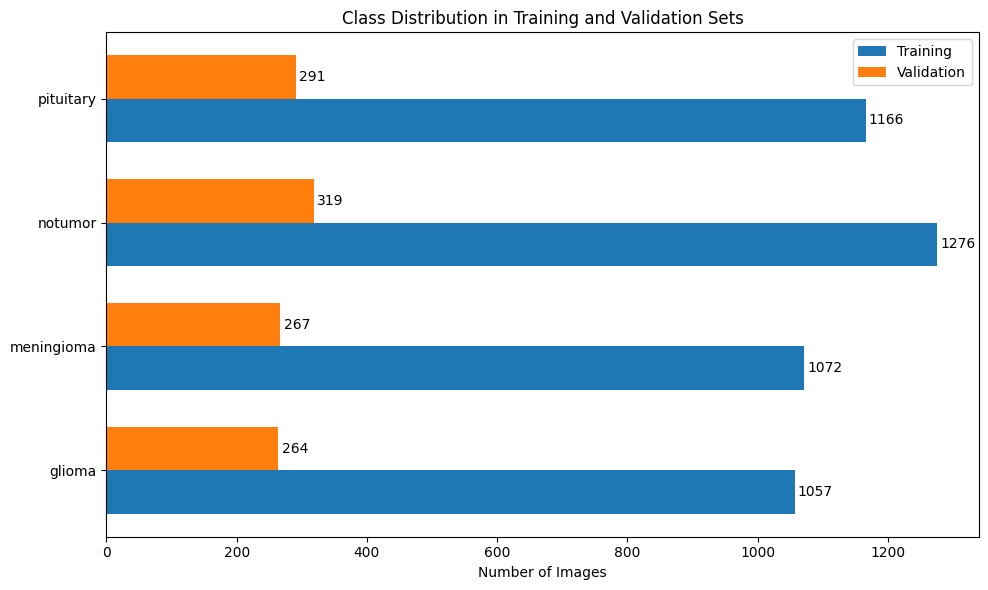

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

classes = list(train_gen.class_indices.keys())

train_counts = np.bincount(train_gen.classes, minlength=len(classes))
val_counts   = np.bincount(val_gen.classes, minlength=len(classes))

y = np.arange(len(classes))
h = 0.35

plt.figure(figsize=(10, 6))
plt.barh(y - h/2, train_counts, h, label='Training')
plt.barh(y + h/2, val_counts,   h, label='Validation')

plt.yticks(y, classes)
plt.xlabel("Number of Images")
plt.title("Class Distribution in Training and Validation Sets")
plt.legend()

for i, v in enumerate(train_counts):
    plt.text(v + 5, i - h/2, str(int(v)), va='center')
for i, v in enumerate(val_counts):
    plt.text(v + 5, i + h/2, str(int(v)), va='center')

plt.tight_layout()
plt.show()


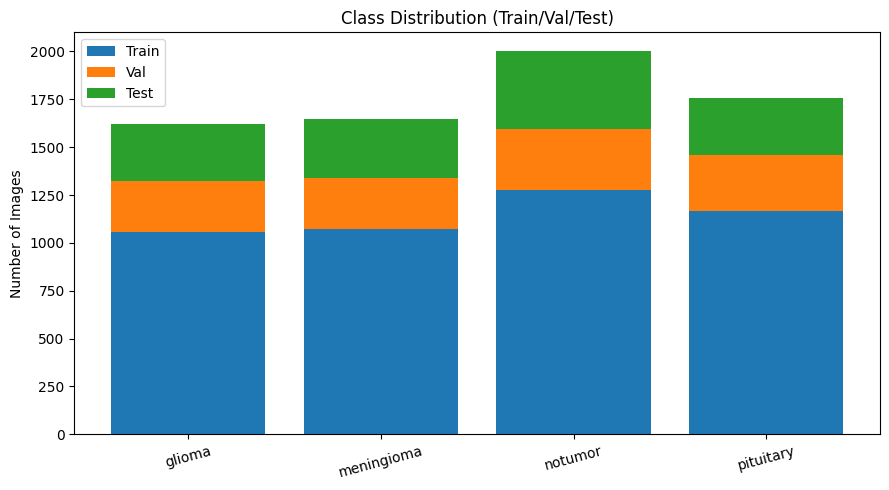

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

classes = list(train_gen.class_indices.keys())

train_counts = np.bincount(train_gen.classes, minlength=len(classes))
val_counts   = np.bincount(val_gen.classes,   minlength=len(classes))
test_counts  = np.bincount(test_gen.classes,  minlength=len(classes))

x = np.arange(len(classes))

plt.figure(figsize=(9,5))
plt.bar(x, train_counts, label="Train")
plt.bar(x, val_counts, bottom=train_counts, label="Val")
plt.bar(x, test_counts, bottom=train_counts+val_counts, label="Test")

plt.xticks(x, classes, rotation=15)
plt.ylabel("Number of Images")
plt.title("Class Distribution (Train/Val/Test)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
labels = list(train_gen.class_indices.keys())
print(labels)


['glioma', 'meningioma', 'notumor', 'pituitary']


Total glioma images: 1321
Randomly selected images:


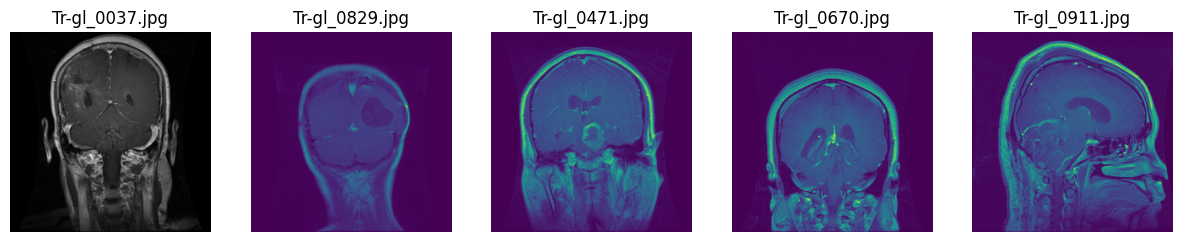

Total meningioma images: 1339
Randomly selected images:


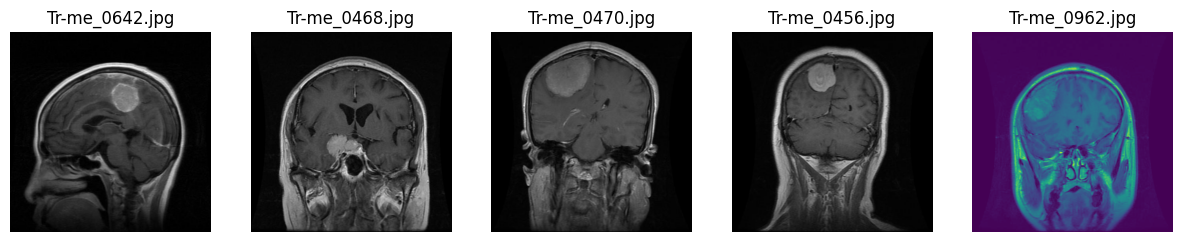

Total notumor images: 1595
Randomly selected images:


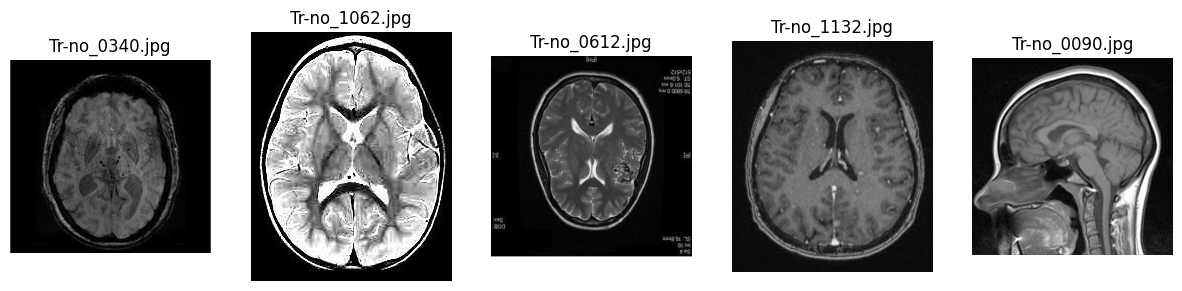

Total pituitary images: 1457
Randomly selected images:


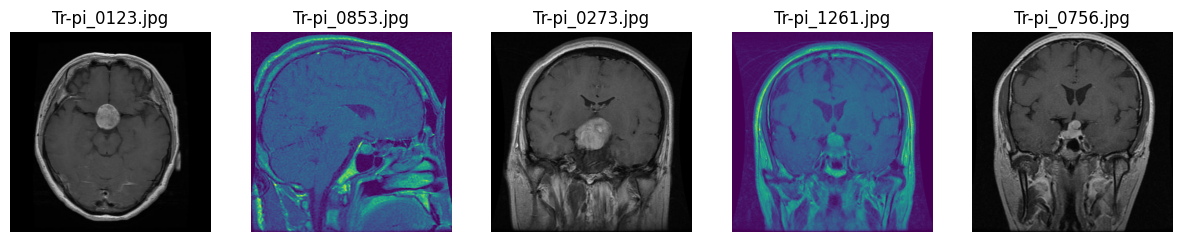

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

folder_path = train_dir
all_labels = list(train_gen.class_indices.keys())

for label in all_labels:
    files = os.listdir(os.path.join(folder_path, label))
    image_files = [f for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))]

    print(f"Total {label} images:", len(image_files))
    print("Randomly selected images:")

    sample_files = random.sample(image_files, min(5, len(image_files)))

    plt.figure(figsize=(15,5))
    for j, fname in enumerate(sample_files, 1):
        img_path = os.path.join(folder_path, label, fname)
        img = Image.open(img_path)

        plt.subplot(1, len(sample_files), j)
        plt.imshow(img)
        plt.title(fname)
        plt.axis("off")

    plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_dir = "Training"
test_dir  = "Testing"

cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = cnn_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_data = cnn_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=SEED
)

cnn_test_datagen = ImageDataGenerator(rescale=1./255)
test_data = cnn_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
x_batch, y_batch = next(train_data)
print(x_batch.min(), x_batch.max())   # لازم 0.0 1.0


0.0 1.0


In [ ]:
from tensorflow.keras.applications.resnet import preprocess_input
preprocessing_function=preprocess_input



In [ ]:

x_batch, y_batch = next(train_data)

print("x shape:", x_batch.shape)
print("y shape:", y_batch.shape)
print("x min / max:", x_batch.min(), x_batch.max())
print("Unique labels in this batch:", set(y_batch.tolist()))


x shape: (32, 224, 224, 3)
y shape: (32,)
x min / max: 0.0 1.0
Unique labels in this batch: {0.0, 1.0, 2.0, 3.0}


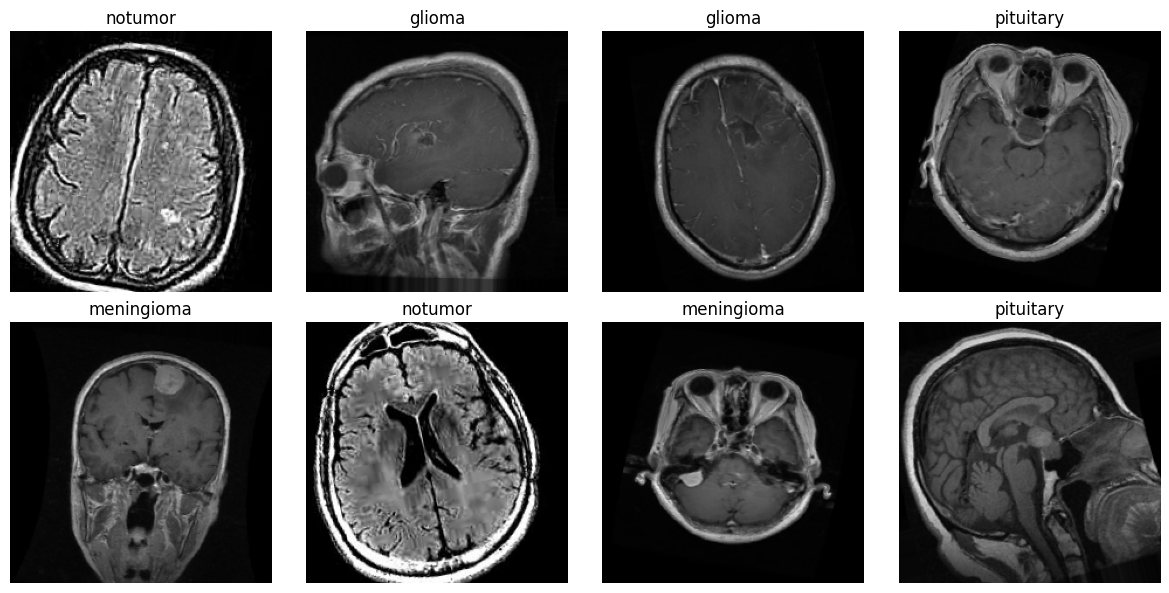

In [ ]:
import matplotlib.pyplot as plt

labels = list(train_data.class_indices.keys())

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_batch[i])
    plt.title(labels[int(y_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_data.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data.classes
)
class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)


Class weights: {np.int32(0): np.float64(1.0811258278145695), np.int32(1): np.float64(1.0659981343283582), np.int32(2): np.float64(0.8955721003134797), np.int32(3): np.float64(0.9800600343053173)}


In [ ]:

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Dense, BatchNormalization, GlobalAveragePooling2D

IMG_SIZE = 224

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])


from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import SparseCategoricalCrossentropy

optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-5)

model.compile(
    optimizer=optimizer,
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early, reduce_lr],


)

test_loss, test_acc = model.evaluate(test_data)
print("Test accuracy:", test_acc)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 96s 580ms/step - accuracy: 0.6205 - loss: 0.9400 - val_accuracy: 0.2550 - val_loss: 3.1590 - learning_rate: 1.0000e-04
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 69s 486ms/step - accuracy: 0.7406 - loss: 0.6726 - val_accuracy: 0.2550 - val_loss: 6.2162 - learning_rate: 1.0000e-04
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 70s 492ms/step - accuracy: 0.7786 - loss: 0.5925 - val_accuracy: 0.2638 - val_loss: 7.9132 - learning_rate: 1.0000e-04
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 69s 484ms/step - accuracy: 0.8129 - loss: 0.5004 - val_accuracy: 0.2691 - val_loss: 6.7122 - learning_rate: 5.0000e-05
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.0361 - loss: 3.6209
Test accuracy: 0.22883294522762299


In [ ]:
train_dir = "/content/Training"
test_dir  = "/content/Testing"


In [ ]:
import os
print(os.path.exists(train_dir), os.path.exists(test_dir))


True True


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_data = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=SEED
)

resnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_data = resnet_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

print("Samples:", train_data.samples, val_data.samples, test_data.samples)
print("Class order:", train_data.class_indices)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Samples: 4571 1141 1311
Class order: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

NUM_CLASSES = 4

base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

hist1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=[early, reduce_lr]
)

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=[early, reduce_lr]
)

test_loss, test_acc = model.evaluate(test_data)
print("ResNet50 Test Accuracy:", test_acc)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 98s 598ms/step - accuracy: 0.3598 - loss: 1.5845 - val_accuracy: 0.6731 - val_loss: 0.9399 - learning_rate: 1.0000e-04
Epoch 2/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 504ms/step - accuracy: 0.6746 - loss: 0.8208 - val_accuracy: 0.6915 - val_loss: 0.8533 - learning_rate: 1.0000e-04
Epoch 3/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 509ms/step - accuracy: 0.7652 - loss: 0.6314 - val_accuracy: 0.7117 - val_loss: 0.8195 - learning_rate: 1.0000e-04
Epoch 4/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 505ms/step - accuracy: 0.8108 - loss: 0.5302 - val_accuracy: 0.7309 - val_loss: 0.7364 - learning_rate: 1.0000e-04
Epoch 5/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 71s 499ms/step - accuracy: 0.8225 - loss: 0.4899 - val_accuracy: 0.7318 - val_loss: 0.7259 - learning_rate: 1.0000e-04
Epoch 6/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 71s 498ms/step - accuracy: 0.8401 - loss: 0.4493 - val_accuracy: 0.7528 - val_loss: 0.6777 - learning_rate: 1.0000e-04
Epoch 7/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 505ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


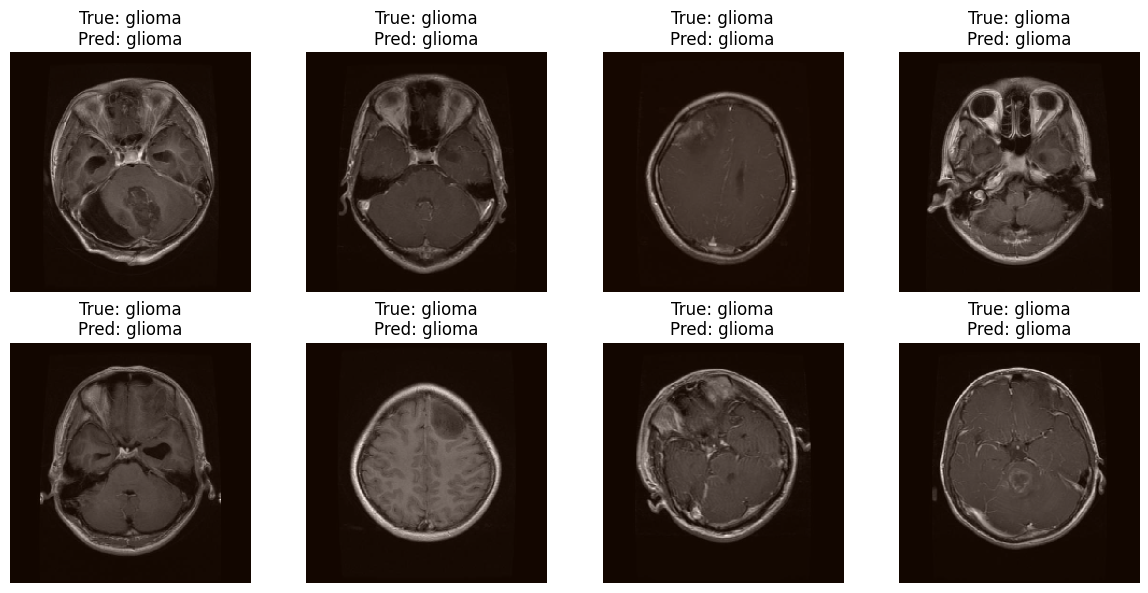

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = list(test_data.class_indices.keys())

x_batch, y_batch = next(test_data)

preds = model.predict(x_batch)
pred_labels = np.argmax(preds, axis=1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow((x_batch[i] - x_batch[i].min()) / (x_batch[i].max() - x_batch[i].min()))
    plt.title(f"True: {class_names[int(y_batch[i])]}\nPred: {class_names[pred_labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:


model_names = [
    "CNN (From Scratch)",
    "ResNet50 (Fine-Tuned)"
]

test_accuracies = [
    0.2288,
    0.9488
]



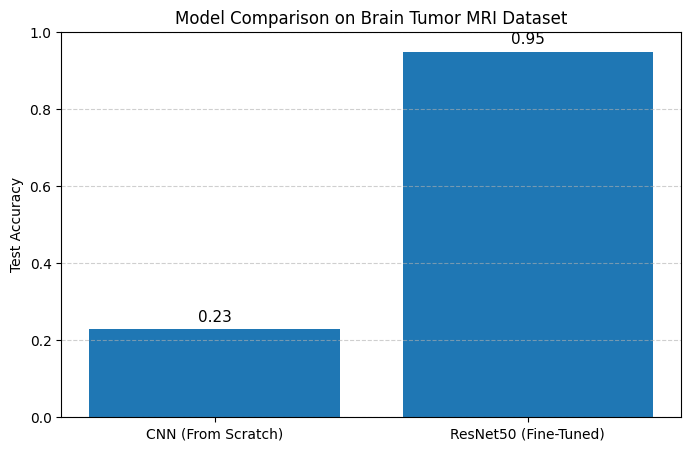

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, test_accuracies)

plt.ylim(0,1)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on Brain Tumor MRI Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center',
        fontsize=11
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


                   Model  Train Acc  Val Acc  Test Acc  \
0          CNN (Scratch)     0.8129   0.2691  0.228833   
1  ResNet50 (Fine-Tuned)     0.9763   0.9299  0.948131   

                             Notes  Gen Gap (Train-Val)  Gain vs CNN (Test)  
0  Overfitting (train↑, val/test↓)               0.5438            0.000000  
1   Good generalization (val≈test)               0.0464            0.719298  


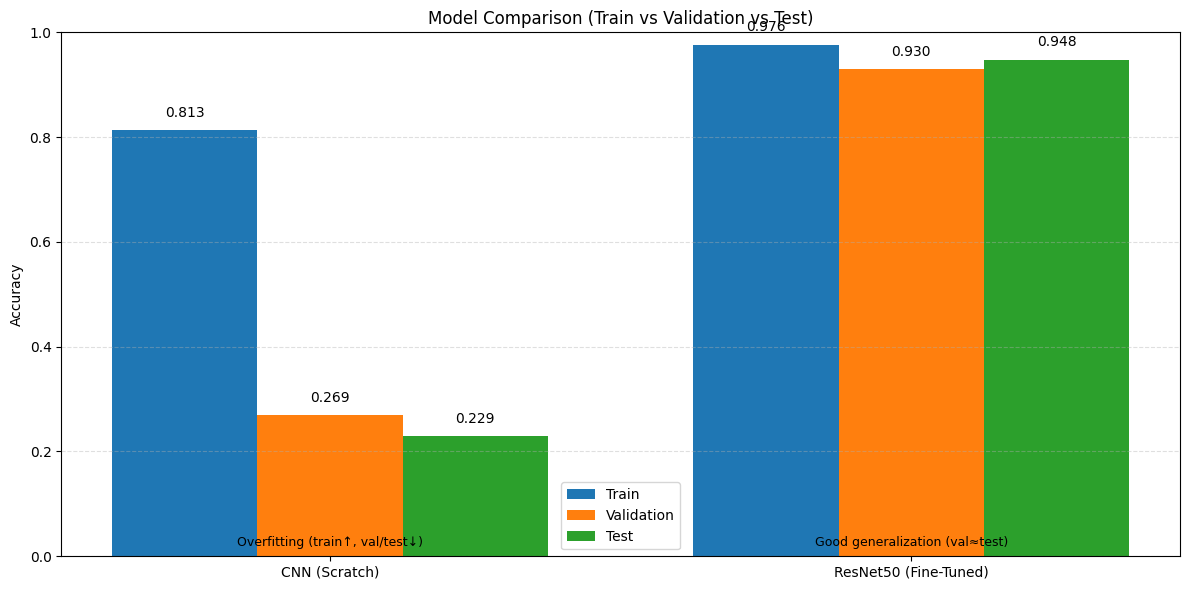

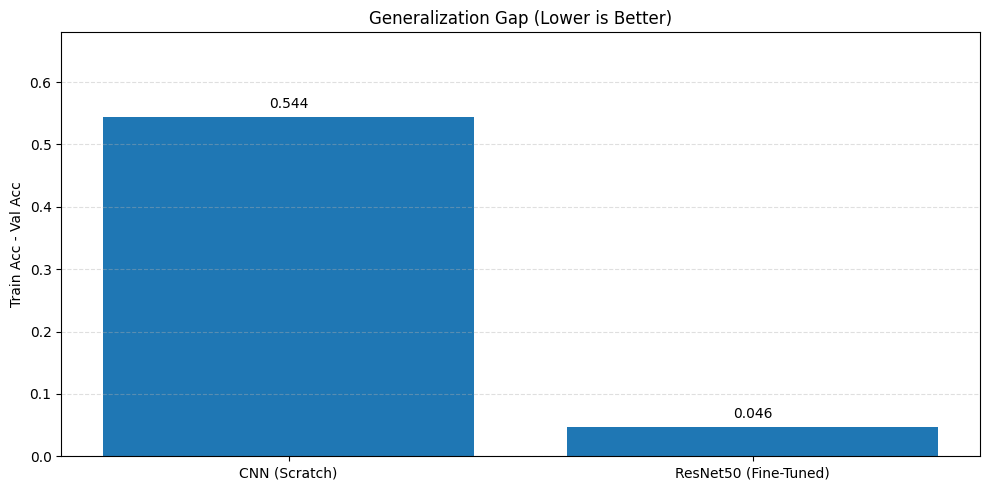

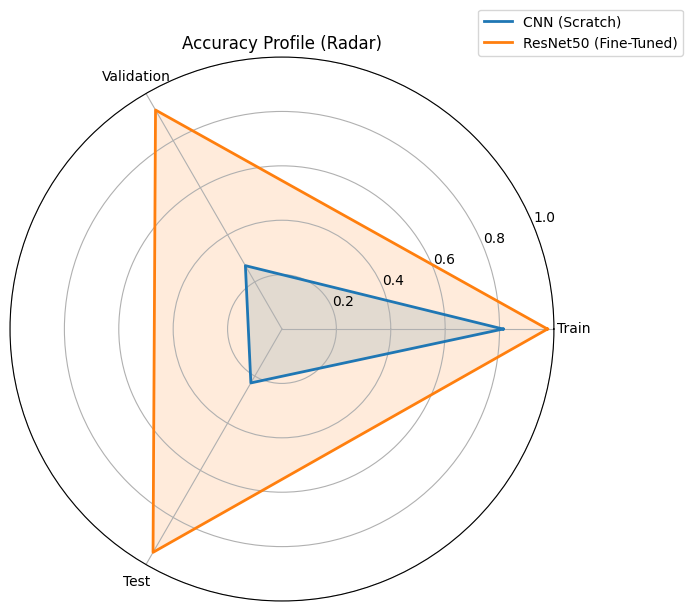

Saved: model_comparison_test_accuracy.png


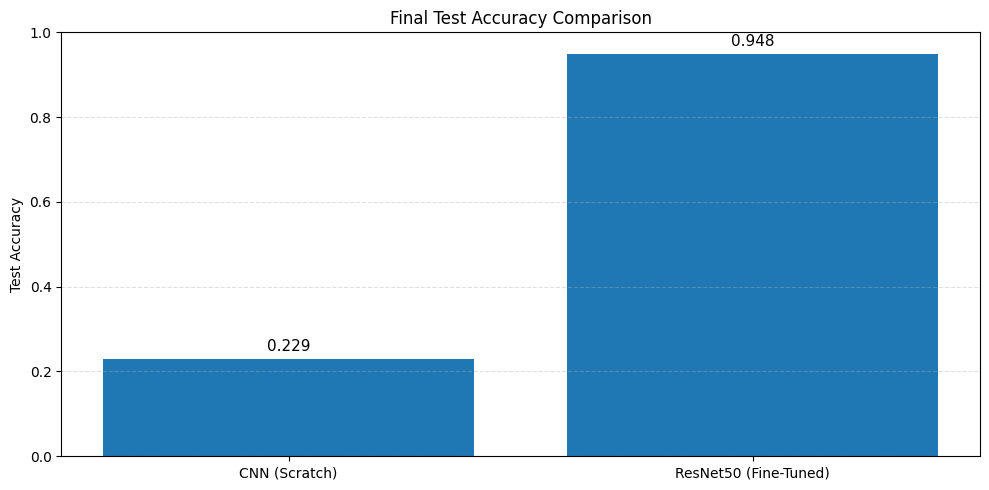

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = ["CNN (Scratch)", "ResNet50 (Fine-Tuned)"]

train_acc = [0.8129, 0.9763]
val_acc   = [0.2691, 0.9299]
test_acc  = [0.22883294522762299, 0.9481312036514282]

notes = [
    "Overfitting (train↑, val/test↓)",
    "Good generalization (val≈test)"
]

df = pd.DataFrame({
    "Model": models,
    "Train Acc": train_acc,
    "Val Acc": val_acc,
    "Test Acc": test_acc,
    "Notes": notes
})

df["Gen Gap (Train-Val)"] = df["Train Acc"] - df["Val Acc"]
df["Gain vs CNN (Test)"]  = df["Test Acc"] - df.loc[0, "Test Acc"]

print(df)

x = np.arange(len(models))
w = 0.25

plt.figure(figsize=(12,6))
b1 = plt.bar(x - w, train_acc, w, label="Train")
b2 = plt.bar(x,      val_acc,   w, label="Validation")
b3 = plt.bar(x + w,  test_acc,  w, label="Test")

plt.ylim(0, 1)
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Train vs Validation vs Test)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=10)

add_labels(b1); add_labels(b2); add_labels(b3)

for i, n in enumerate(notes):
    plt.text(i, 0.02, n, ha="center", fontsize=9)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
gap = df["Gen Gap (Train-Val)"].values
bars = plt.bar(models, gap)

plt.ylim(0, max(gap)*1.25 if max(gap) > 0 else 0.1)
plt.ylabel("Train Acc - Val Acc")
plt.title("Generalization Gap (Lower is Better)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h + (0.01 if h>0 else 0.005),
             f"{h:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

labels = ["Train", "Validation", "Test"]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

def radar_values(a, b, c):
    vals = [a, b, c]
    return vals + vals[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

cnn_vals    = radar_values(train_acc[0], val_acc[0], test_acc[0])
resnet_vals = radar_values(train_acc[1], val_acc[1], test_acc[1])

ax.plot(angles, cnn_vals, linewidth=2, label="CNN (Scratch)")
ax.fill(angles, cnn_vals, alpha=0.15)

ax.plot(angles, resnet_vals, linewidth=2, label="ResNet50 (Fine-Tuned)")
ax.fill(angles, resnet_vals, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
plt.title("Accuracy Profile (Radar)")
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(models, test_acc)
plt.ylim(0,1)
plt.ylabel("Test Accuracy")
plt.title("Final Test Accuracy Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for i, v in enumerate(test_acc):
    plt.text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison_test_accuracy.png", dpi=200)
print("Saved: model_comparison_test_accuracy.png")


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

eff_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

eff_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_eff = eff_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training"
)

val_eff = eff_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation"
)

test_eff = eff_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

print("Samples:", train_eff.samples, val_eff.samples, test_eff.samples)
print("Class order:", train_eff.class_indices)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Samples: 4571 1141 1311
Class order: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(4, activation="softmax")(x)

eff_model = Model(inputs=base_model.input, outputs=output)

eff_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

eff_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_eff = eff_model.fit(
    train_eff,
    validation_data=val_eff,
    epochs=6
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 124s 686ms/step - accuracy: 0.5556 - loss: 1.0299 - val_accuracy: 0.6880 - val_loss: 0.8246
Epoch 2/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 460ms/step - accuracy: 0.8311 - loss: 0.4744 - val_accuracy: 0.7388 - val_loss: 0.6917
Epoch 3/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 464ms/step - accuracy: 0.8679 - loss: 0.3941 - val_accuracy: 0.7520 - val_loss: 0.6140
Epoch 4/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 65s 457ms/step - accuracy: 0.8781 - loss: 0.3559 - val_accuracy: 0.7774 - val_loss: 0.5720
Epoch 5/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 465ms/step - accuracy: 0.8907 - loss: 0.3124 - val_accuracy: 0.7844 - val_loss: 0.5489
Epoch 6/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 460ms/step - accuracy: 0.8945 - loss: 0.3116 - val_accuracy: 0.7879 - val_loss: 0.5294


In [ ]:
test_loss, test_acc = eff_model.evaluate(test_eff)
print("EfficientNetB0 Test Accuracy:", test_acc)


41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 311ms/step - accuracy: 0.7370 - loss: 0.6386
EfficientNetB0 Test Accuracy: 0.8291380405426025


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_model(model, test_gen, title="Model"):
    y_true = test_gen.classes
    probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{title} Test Accuracy: {acc:.4f}\n")

    class_names = list(test_gen.class_indices.keys())
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} - Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=20)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return acc, cm


In [ ]:
[m for m in globals() if "model" in m.lower()]



['model',
 'Model',
 'model_names',
 'models',
 'base_model',
 'eff_model',
 'evaluate_model']


ResNet50 (Fine-Tuned) Test Accuracy: 0.9481

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9558    0.9367    0.9461       300
  meningioma     0.9331    0.8660    0.8983       306
     notumor     0.9522    0.9827    0.9672       405
   pituitary     0.9492    0.9967    0.9724       300

    accuracy                         0.9481      1311
   macro avg     0.9476    0.9455    0.9460      1311
weighted avg     0.9479    0.9481    0.9475      1311



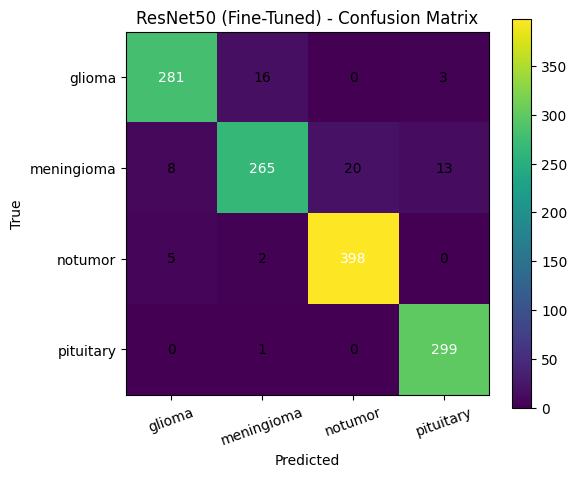

(0.9481311975591151,
 array([[281,  16,   0,   3],
        [  8, 265,  20,  13],
        [  5,   2, 398,   0],
        [  0,   1,   0, 299]]))

In [ ]:
evaluate_model(model, test_data, title="ResNet50 (Fine-Tuned)")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_any_model(model, test_gen, title="Model"):
    y_true = test_gen.classes
    probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ {title} | Test Accuracy: {acc:.4f}")

    class_names = list(test_gen.class_indices.keys())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} - Confusion Matrix")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=20)
    plt.yticks(ticks, class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return acc, cm

def evaluate_all(models_list):
    results = {}
    for name, model, test_gen in models_list:
        acc, cm = evaluate_any_model(model, test_gen, title=name)
        results[name] = {"test_acc": acc, "cm": cm}
    return results


In [ ]:
[m for m in globals() if "model" in m.lower()]


['model',
 'Model',
 'model_names',
 'models',
 'base_model',
 'eff_model',
 'evaluate_model',
 'evaluate_any_model']


Evaluating ResNet50 (Fine-Tuned)

ResNet50 (Fine-Tuned) Test Accuracy: 0.9481

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9558    0.9367    0.9461       300
  meningioma     0.9331    0.8660    0.8983       306
     notumor     0.9522    0.9827    0.9672       405
   pituitary     0.9492    0.9967    0.9724       300

    accuracy                         0.9481      1311
   macro avg     0.9476    0.9455    0.9460      1311
weighted avg     0.9479    0.9481    0.9475      1311



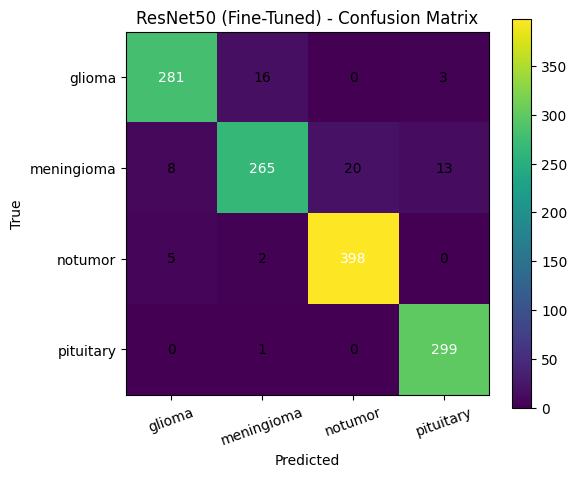


Evaluating EfficientNetB0

EfficientNetB0 Test Accuracy: 0.8291

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9009    0.6967    0.7857       300
  meningioma     0.7033    0.6275    0.6632       306
     notumor     0.9279    0.9531    0.9403       405
   pituitary     0.7692    1.0000    0.8696       300

    accuracy                         0.8291      1311
   macro avg     0.8253    0.8193    0.8147      1311
weighted avg     0.8330    0.8291    0.8241      1311



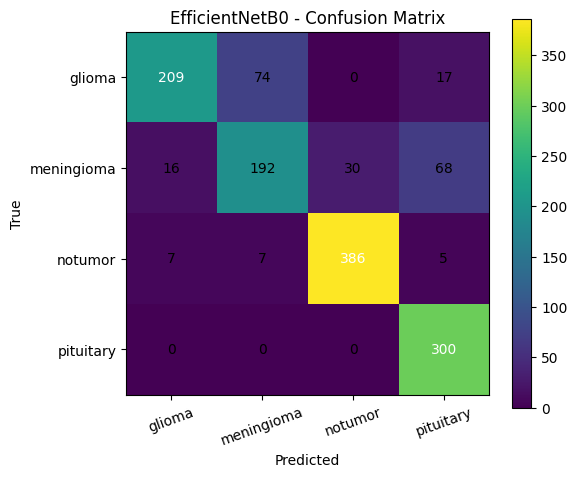

In [ ]:
models_to_eval = [
    ("ResNet50 (Fine-Tuned)", model, test_data),
    ("EfficientNetB0", eff_model, test_eff)
]

for name, mdl, data in models_to_eval:
    print(f"\nEvaluating {name}")
    evaluate_model(mdl, data, title=name)


In [ ]:
import json
import tensorflow as tf

model.save("resnet_brain_tumor.keras")

class_names = list(test_data.class_indices.keys())
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved model + class names:", class_names)


Saved model + class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from google.colab import files
files.download("resnet_brain_tumor.keras")
files.download("class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
import tensorflow as tf

eff_model.save("efficientnet_brain_tumor.keras")

class_names = list(test_eff.class_indices.keys())
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved EfficientNet + class names:", class_names)


Saved EfficientNet + class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from google.colab import files
files.download("efficientnet_brain_tumor.keras")
files.download("class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("cnn_brain_tumor.keras")

import json
class_names = list(test_data.class_indices.keys())
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved CNN model + class names:", class_names)


Saved CNN model + class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
model.save("cnn_brain_tumor.keras")


In [ ]:
eff_model.save("efficientnet_brain_tumor.keras")



In [ ]:
model.save("resnet_brain_tumor.keras")
print("ResNet model saved")



ResNet model saved


In [ ]:
import os
print(os.listdir())


['.config', 'class_names.json', 'cnn_brain_tumor.keras', 'Training', 'Testing', 'model_comparison_test_accuracy.png', 'archive.zip', 'resnet_brain_tumor.keras', 'efficientnet_brain_tumor.keras', 'sample_data']


In [ ]:
import tensorflow as tf
import json

model = tf.keras.models.load_model("resnet_brain_tumor.keras")
with open("class_names.json") as f:
    class_names = json.load(f)

print("Model loaded OK")
print("Classes:", class_names)


Model loaded OK
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        if hasattr(layer, "layers"):
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    return sub.name
    raise ValueError("No Conv2D layer found. Please specify last_conv_layer_name manually.")

def preprocess_for_model(img_pil, img_size=(224,224), mode="rescale_0_1"):
    img = img_pil.convert("RGB").resize(img_size)
    arr = np.array(img).astype(np.float32)

    if mode == "rescale_0_1":
        arr = arr / 255.0
    elif mode == "resnet":
        arr = tf.keras.applications.resnet.preprocess_input(arr)
    elif mode == "efficientnet":
        arr = tf.keras.applications.efficientnet.preprocess_input(arr)
    else:
        raise ValueError("mode must be one of: rescale_0_1, resnet, efficientnet")

    arr = np.expand_dims(arr, axis=0)
    return img, arr

def grad_cam(model, img_array, last_conv_layer_name, class_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_score = preds[:, class_index]

    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img_pil, heatmap, alpha=0.35):

    img = np.array(img_pil).astype(np.float32)
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy().squeeze()

    cmap = plt.get_cmap("jet")
    colored = cmap(heatmap_resized)[..., :3] * 255.0

    overlay = img*(1-alpha) + colored*alpha
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return overlay

def explain_prediction_text(pred_class, confidence, all_scores):

    sorted_scores = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)
    top2 = sorted_scores[:2]

    return (
        f"Prediction: {pred_class}  |  Confidence: {confidence*100:.2f}%\n"
        f"Model reasoning (explainability): the highlighted (red/yellow) region is where the model focused most.\n"
        f"Top alternatives:\n"
        f"1) {top2[0][0]}: {top2[0][1]*100:.2f}%\n"
        f"2) {top2[1][0]}: {top2[1][1]*100:.2f}%\n"
        f"Note: This is NOT a medical diagnosis—only an AI model explanation."
    )


In [ ]:

backbone = model.get_layer("resnet50")

last_conv = None
for layer in reversed(backbone.layers):
    if "conv" in layer.name.lower() and hasattr(layer, "kernel_size"):
        last_conv = layer.name
        break

print("Last conv layer inside resnet50:", last_conv)


Last conv layer inside resnet50: conv5_block3_3_conv


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

def make_heatmap(model, img_array, backbone_name="resnet50", last_conv_name="conv5_block3_3_conv", pred_index=None):
    backbone = model.get_layer(backbone_name)
    last_conv_layer = backbone.get_layer(last_conv_name)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_heatmap(original_img_pil, heatmap, alpha=0.35):
    img = np.array(original_img_pil)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return overlay


In [ ]:
import json
import numpy as np
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

with open("class_names.json") as f:
    class_names = json.load(f)

def predict_with_reason(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    preds = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(preds))
    pred_label = class_names[pred_idx]
    confidence = float(preds[pred_idx])

    heatmap, _ = make_heatmap(model, x, last_conv_name="conv5_block3_3_conv", pred_index=pred_idx)
    overlay = overlay_heatmap(img, heatmap, alpha=0.35)

    print("Pred:", pred_label, "| Confidence:", round(confidence*100, 2), "%")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(overlay); plt.title("Grad-CAM (Reason)"); plt.axis("off")
    plt.show()

    return pred_label, confidence



In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Uploaded image:", img_path)


Saving Te-gl_0250.jpg to Te-gl_0250.jpg
Uploaded image: Te-gl_0250.jpg


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 224

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

preds = model.predict(img_array)
pred_idx = np.argmax(preds)
confidence = preds[0][pred_idx]

print("Predicted class index:", pred_idx)
print("Confidence:", confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class index: 0
Confidence: 0.85205007


In [ ]:
import json

with open("class_names.json") as f:
    class_names = json.load(f)

pred_class = class_names[pred_idx]

print("🧠 Predicted Tumor Type:", pred_class)
print("🔢 Confidence:", f"{confidence*100:.2f}%")


🧠 Predicted Tumor Type: glioma
🔢 Confidence: 85.21%


In [ ]:
def explain_prediction(pred_class):
    reasons = {
        "glioma": "Irregular patterns and infiltrative growth within brain tissue.",
        "meningioma": "Well-defined tumor boundaries, often located near the skull.",
        "pituitary": "Tumor located in the pituitary gland region.",
        "notumor": "No clear radiological signs indicating the presence of a tumor."
    }
    return reasons.get(pred_class, "No explanation available.")

print("📌 Explanation:", explain_prediction(pred_class))


📌 Explanation: Irregular patterns and infiltrative growth within brain tissue.
